# Day 26 - CLIP - 图文对比学习

> 目标: 理解 CLIP 如何把图像和文本映射到同一个向量空间
>
> 核心: 对比学习 — 匹配的图文对拉近, 不匹配的推远

---

## CLIP 的核心思想

```
过去:       给图像打标签 (ImageNet 1000 类) → 只能识别这 1000 种
CLIP:       用文本描述代替标签 → "a photo of a dog" 就是标签

优点:
  - 零样本迁移: 没见过 "zebra" 也能识别 (因为知道文字 "zebra")
  - 灵活: 想识别什么就写什么文本
  - 多模态: 图文互相检索

架构:
  Image ← Image Encoder →                      → Text Encoder → Text
  (ViT/ResNet)              对比学习               (Transformer)
```

### 对比学习 (Contrastive Learning)

```
训练数据: 4 亿张 (图像, 文本) 配对

每个 batch 有 N 对 (img, text)
  → 图像编码成 N 个向量
  → 文本编码成 N 个向量
  → 计算 N×N 相似度矩阵
  → 对角线 = 正样本 (匹配的图文对)
  → 非对角线 = 负样本 (不匹配的)
  → 损失: 让对角线高, 非对角线低
```

In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'
os.environ['HF_HOME'] = 'D:\\hyy\\vscode\\vscode模型'

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

print('=' * 40)
print('Day 26 - CLIP')
print('=' * 40)

Day 26 - CLIP


## 1. 加载预训练 CLIP 模型

> 用 HuggingFace 的 CLIP, 看它怎么理解图文匹配

In [3]:
from transformers import CLIPProcessor, CLIPModel

model_name = 'openai/clip-vit-base-patch32'
print(f'加载 {model_name}...')

clip_model = CLIPModel.from_pretrained(model_name)
clip_processor = CLIPProcessor.from_pretrained(model_name)

params = sum(p.numel() for p in clip_model.parameters())
print(f'CLIP 参数量: {params:,}')
print(f'  Image Encoder: {sum(p.numel() for p in clip_model.vision_model.parameters()):,}')
print(f'  Text Encoder:  {sum(p.numel() for p in clip_model.text_model.parameters()):,}')

加载 openai/clip-vit-base-patch32...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIP 参数量: 151,277,313
  Image Encoder: 87,456,000
  Text Encoder:  63,165,952


C:\Users\hyy\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in D:\hyy\vscode\vscode模型\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


## 2. 零样本图像分类

> 不用任何训练数据, 直接用 CLIP 分类
>
> 原理: 把候选类别写成句子, 看图像跟哪个句子最相似

In [19]:
# ============================================
# 生成随机图像, 模拟分类
# ============================================

# 用随机图像代替真实图像 (演示流程)
random_image = torch.randint(0, 255, (1, 3, 224, 224), dtype=torch.uint8).numpy()

# 候选类别
candidate_labels = ['dog', 'cat', 'car', 'plane', 'sunset', 'ocean']
texts = [f'a photo of a {c}' for c in candidate_labels]

# 预处理
inputs = clip_processor(images=random_image, text=texts,
                        padding=True, return_tensors='pt')

with torch.no_grad():
    outputs = clip_model(**inputs)
    logits_per_image = outputs.logits_per_image  # (1, num_texts)
    probs = logits_per_image.softmax(dim=1).squeeze()

print('零样本分类结果 (随机图像, 仅供流程演示):')
print('=' * 40)
for label, prob in zip(candidate_labels, probs):
    bar = '█' * int(prob * 30)
    print(f'  {label:>8s}  {prob.item():.1%}  {bar}')
print()
print('随机图像没有真实语义, 所以概率分布较均匀')
print('如果换成真实图像, CLIP 能准确匹配对应的文字')

零样本分类结果 (随机图像, 仅供流程演示):
       dog  25.2%  ███████
       cat  22.3%  ██████
       car  8.8%  ██
     plane  2.4%  
    sunset  0.3%  
     ocean  41.1%  ████████████

随机图像没有真实语义, 所以概率分布较均匀
如果换成真实图像, CLIP 能准确匹配对应的文字


## 3. 手写对比损失 (Contrastive Loss)

> 这是 CLIP 训练的核心

D:\hyy\Temp\ipykernel_28488\3927240169.py:68: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\hyy\Temp\ipykernel_28488\3927240169.py:68: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\hyy\Temp\ipykernel_28488\3927240169.py:68: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\hyy\Temp\ipykernel_28488\3927240169.py:68: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\hyy\Temp\ipykernel_28488\3927240169.py:68: UserWarning: Glyph 35282 (\N{CJK UNIFIED IDEOGRAPH-89D2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\hyy\Temp\ipykernel_28488\3927240169.py:68: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\hyy\Temp\ipykernel_28488\3927240169.py:69: 

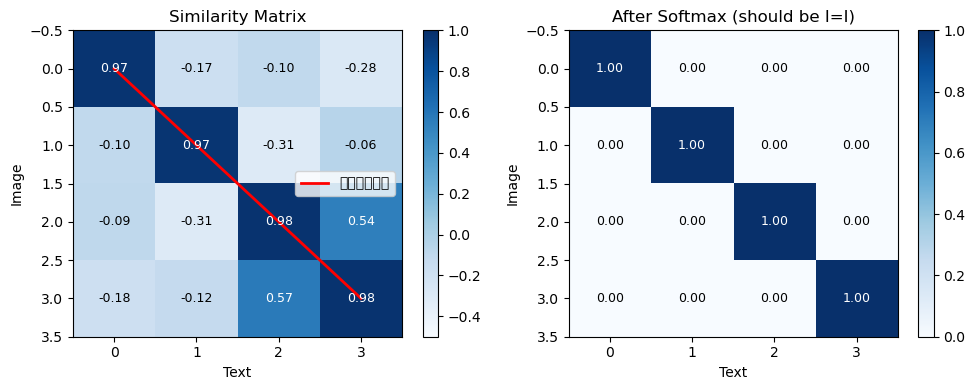

对比损失: 0.0012 (越小越好)


In [20]:
# ============================================
# 模拟 CLIP 对比损失
# ============================================

def contrastive_loss(image_embeds, text_embeds, temperature=0.07):
    """CLIP 对比损失
    
    输入:
      image_embeds: (batch, d) 归一化后的图像向量
      text_embeds:  (batch, d) 归一化后的文本向量
    """
    batch = image_embeds.shape[0]
    
    # 相似度矩阵 (batch, batch)
    logits = image_embeds @ text_embeds.T / temperature
    
    # 标签: 对角线是正样本 (每个图像对应自己配对的文本)
    labels = torch.arange(batch)
    
    # 双向交叉熵
    loss_i = F.cross_entropy(logits, labels)  # 图像→文本
    loss_t = F.cross_entropy(logits.T, labels)  # 文本→图像
    
    return (loss_i + loss_t) / 2


# 模拟一个 batch 的图文嵌入
batch, dim = 4, 16
torch.manual_seed(42)

# 模拟: 正样本对互相相似, 负样本不相似
image_embeds = torch.randn(batch, dim)
text_embeds = image_embeds + torch.randn(batch, dim) * 0.3  # 文本跟对应图像接近

image_embeds = F.normalize(image_embeds, dim=1)
text_embeds = F.normalize(text_embeds, dim=1)

loss = contrastive_loss(image_embeds, text_embeds)

# 可视化相似度矩阵
sim = (image_embeds @ text_embeds.T).numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
im = ax.imshow(sim, cmap='Blues', aspect='auto', vmin=-0.5, vmax=1)
ax.set_xlabel('Text'); ax.set_ylabel('Image')
ax.set_title('Similarity Matrix')
plt.colorbar(im, ax=ax)
for i in range(batch):
    for j in range(batch):
        c = 'white' if sim[i,j] > 0.5 else 'black'
        ax.text(j, i, f'{sim[i,j]:.2f}', ha='center', va='center', fontsize=9, color=c)
ax.plot(range(batch), range(batch), 'r-', lw=2, label='正样本对角线')
ax.legend()

ax = axes[1]
probs = F.softmax(torch.tensor(sim) / 0.07, dim=1).numpy()
im = ax.imshow(probs, cmap='Blues', aspect='auto', vmin=0, vmax=1)
ax.set_xlabel('Text'); ax.set_ylabel('Image')
ax.set_title('After Softmax (should be I=I)')
plt.colorbar(im, ax=ax)
for i in range(batch):
    for j in range(batch):
        c = 'white' if probs[i,j] > 0.5 else 'black'
        ax.text(j, i, f'{probs[i,j]:.2f}', ha='center', va='center', fontsize=9, color=c)

plt.tight_layout()
plt.savefig('day26_contrastive_loss.png', dpi=100)
plt.show()
print(f'对比损失: {loss.item():.4f} (越小越好)')

## 4. 图文检索演示

> 用随机嵌入模拟 CLIP 的图文检索流程
>
> 正式使用时: 用真实图像提取特征

In [21]:
# ============================================
# 模拟: 用文本搜索图像
# ============================================

# 模拟图像库 (10 张随机向量)
db_size = 10
image_db = F.normalize(torch.randn(db_size, 64), dim=1)
image_names = [f'img_{i}.jpg' for i in range(db_size)]

# 模拟文本查询
query = F.normalize(torch.randn(64), dim=0)

# 检索: 算文本跟所有图像的相似度
scores = image_db @ query  # (10,)
top3 = scores.topk(3)

print('文本→图像 检索结果 (Top-3):')
for score, idx in zip(top3.values, top3.indices):
    print(f'  {image_names[idx]}: 相似度 = {score.item():.4f}')

print()
print('实际应用中:')
print('  1. 把所有图像用 Image Encoder 转成向量, 存入数据库')
print('  2. 搜索时把文本用 Text Encoder 转成向量')
print('  3. 算相似度, 取 Top-K')

文本→图像 检索结果 (Top-3):
  img_3.jpg: 相似度 = 0.2474
  img_7.jpg: 相似度 = 0.1781
  img_0.jpg: 相似度 = 0.1286

实际应用中:
  1. 把所有图像用 Image Encoder 转成向量, 存入数据库
  2. 搜索时把文本用 Text Encoder 转成向量
  3. 算相似度, 取 Top-K


## 5. 手写简易 CLIP (流程演示)

> 理解完整训练流程: Dual Encoder + 对比损失

In [22]:
# ============================================
# 简易 CLIP 模型结构 (仅演示)
# ============================================

class SimpleImageEncoder(nn.Module):
    """简易图像编码器: 用 MLP 模拟"""
    def __init__(self, img_dim=784, d_model=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(img_dim, 256), nn.ReLU(),
            nn.Linear(256, d_model),
        )
    def forward(self, x):
        return F.normalize(self.net(x), dim=1)

class SimpleTextEncoder(nn.Module):
    """简易文本编码器: 用 MLP 模拟"""
    def __init__(self, vocab_size=100, embed_dim=32, d_model=64):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.net = nn.Sequential(
            nn.Linear(embed_dim, 256), nn.ReLU(),
            nn.Linear(256, d_model),
        )
    def forward(self, x):
        x = self.embed(x).mean(dim=1)  # 平均池化
        return F.normalize(self.net(x), dim=1)

class SimpleCLIP(nn.Module):
    def __init__(self, img_dim=784, vocab_size=100, d_model=64):
        super().__init__()
        self.image_encoder = SimpleImageEncoder(img_dim, d_model)
        self.text_encoder = SimpleTextEncoder(vocab_size, d_model=d_model)

    def forward(self, images, texts):
        img_emb = self.image_encoder(images)
        txt_emb = self.text_encoder(texts)
        return img_emb, txt_emb

clip = SimpleCLIP()
print(f'简易 CLIP 参数量: {sum(p.numel() for p in clip.parameters()):,}')

# 测试前向
imgs = torch.randn(8, 784)
txts = torch.randint(0, 100, (8, 10))
img_e, txt_e = clip(imgs, txts)
print(f'图像嵌入: {tuple(img_e.shape)}')
print(f'文本嵌入: {tuple(txt_e.shape)}')
print(f'向量已归一化, 行和: {img_e[0].norm():.2f}, {txt_e[0].norm():.2f}')

简易 CLIP 参数量: 245,504
图像嵌入: (8, 64)
文本嵌入: (8, 64)
向量已归一化, 行和: 1.00, 1.00


Step  100/500 | Contrastive Loss = 2.8570
Step  200/500 | Contrastive Loss = 2.9208
Step  300/500 | Contrastive Loss = 2.7618
Step  400/500 | Contrastive Loss = 2.6939
Step  500/500 | Contrastive Loss = 2.7525


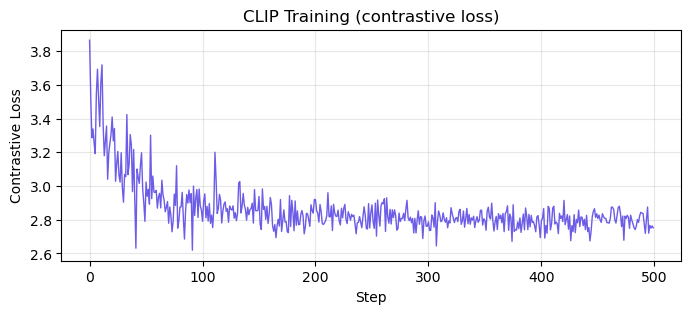

In [23]:
# ============================================
# 训练简易 CLIP (模拟数据)
# ============================================

clip = SimpleCLIP()
opt = torch.optim.AdamW(clip.parameters(), lr=3e-4)

losses = []
for step in range(500):
    imgs = torch.randn(16, 784)
    txts = torch.randint(0, 100, (16, 10))

    img_e, txt_e = clip(imgs, txts)
    loss = contrastive_loss(img_e, txt_e)

    opt.zero_grad()
    loss.backward()
    opt.step()
    losses.append(loss.item())

    if (step + 1) % 100 == 0:
        print(f'Step {step+1:>4d}/500 | Contrastive Loss = {loss.item():.4f}')

plt.figure(figsize=(8, 3))
plt.plot(losses, lw=1, color='#6c5ce7')
plt.xlabel('Step'); plt.ylabel('Contrastive Loss')
plt.title('CLIP Training (contrastive loss)')
plt.grid(alpha=0.3)
plt.savefig('day26_clip_loss.png', dpi=100)
plt.show()

## 6. CLIP 的应用

### 零样本分类

```
不需要任何训练数据!

给一张猫的图片 + ["dog", "cat", "car"]
  → 图像编码成向量
  → "a photo of a dog" 编码成向量
  → "a photo of a cat" 编码成向量
  → "a photo of a car" 编码成向量
  → 看图像跟哪个文本最相似
```

### 图文检索

```
文本→图像: 输入 "a black cat" → 在图像库找到最匹配的
图像→文本: 输入一张图 → 找到最匹配的描述文本
```

### 多模态应用

| 应用 | 怎么用 CLIP |
|:----|:-----------|
| **Stable Diffusion** | 用 CLIP Text Encoder 编码文本条件 |
| **DALL·E** | 用 CLIP 做图像-文本对齐 |
| **图像搜索** | 用自然语言搜图 |
| **目标检测** | CLIP + 区域提议 = 开集检测 |
| **视频理解** | 逐帧用 CLIP 编码 + 时序聚合 |

---

# Day 26 完成!

## 总结

| 概念 | 一句话 |
|------|--------|
| **CLIP** | 双编码器 (Image + Text), 对比学习训练 |
| **对比损失** | 匹配图文拉近, 不匹配推远 |
| **零样本分类** | 写候选类别文字, 看图像跟谁最像 |
| **图文检索** | 图像向量 ↔ 文本向量, 算相似度 |
| **多模态** | 一个模型同时理解图像和文本 |

**第 4 周路线:**

```
Day 22 BERT   → 文本双向理解
Day 23 GPT   → 文本生成
Day 24 nanoGPT → 从零手写 GPT
Day 25 ViT   → 图像理解 (Transformer)
Day 26 CLIP  → 图文结合 (双编码器)
Day 27 GAN   → 图像生成 (生成对抗)
Day 28 SD    → 文生图 (扩散模型)
```

## 作业 (2 题)

### 1. 改 temperature
**位置:** cell-8, `contrastive_loss()` 参数 `temperature=0.07`

改成 0.01 和 1.0, 观察 softmax 后的概率分布有什么变化

<details>
<summary>📖 答案</summary>
temperature=0.01: softmax 变成"one-hot", 最大概率接近 1, 其他接近 0
                  梯度很陡, 不好训练
temperature=1.0:  softmax 变得平滑, 梯度小, 收敛慢
CLIP 用 0.07 是因为归一化后的向量内积在 [-1,1]
除以 0.07 → 放大到 [-14, 14] → softmax 梯度合适
</details>

### 2. 理解零样本
**位置:** cell-5, `candidate_labels` 列表

如果 `candidate_labels` 改成 「"a photo of a dog", "a photo of a cat"」, 和 「"dog", "cat"」 (不加 "a photo of"), 结果有区别吗? 为什么?

<details>
<summary>📖 答案</summary>
有区别。CLIP 预训练时用的文本格式是 "a photo of a {label}"
训练数据里的文本大多长这样
所以推理时用同样模板效果最好
这也是 prompt engineering 的起源
</details>